### Building Chatbot with Tools


##### Using search engine as a tool

In [9]:

from typing import Annotated

from typing_extensions import TypedDict

# use reducers to store the messages instead of replacing in any type of variable we are going to define
from langgraph.graph.message import add_messages


In [10]:
#this state class is going to return a dictionary  
class State(TypedDict):
  # messages have the type list 
  # the add_messages function in the annotation define how this state key should be updated
  # so in ths case , it appends messages in the list, instead of overwriting them  
  
  
  #inside annotated we are saying hey you have to go ahead and add the messages inside a list type with the help of a reducer which is add_messages
  messages:Annotated[list,add_messages]
#use graph builder to make graph
#use Stategraph and pass teh state class created above in it
graph_builder = StateGraph(State)


In [11]:
graph_builder #so we have made our state graph

### Now load the llm

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
#if you want to directly initialize groq model
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000191AADA5940>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000191AADA63C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Starting with the tools

In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95508945,
   'raw_content': None},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangC

##### Making custom function

In [15]:
#write function and generate docstring
#docstrings are important because once we bind any function with our llm then this function will be used as a tool
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [16]:
# create variable tools and write the name of the first tool and the function to be used as a second tool
tools = [tool, multiply] #so now we have a list of tools

In [17]:
# now we need to bind this list of tools with the llm
llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools #now we have binded our llm groq with travily and our custom function

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000191AADA5940>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000191AADA63C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

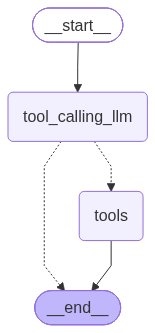

In [19]:
# stategraph
from langgraph.graph import StateGraph,START,END
# all the tools that we have created needs to be converted into a tool node
from langgraph.prebuilt import ToolNode
#
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

## Create graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm" , tool_calling_llm)
graph_builder.add_node("tools" , ToolNode(tools))

# add the edges
graph_builder.add_edge(START , "tool_calling_llm")
#from the tool calling llm there are two edges. one to the tools and other to the end
# so its a conditional edge
graph_builder.add_conditional_edges(
    "tool_calling_llm",
    #if teh latest mesage from the assistant is a tool call -> tools_condition routes to tools
    #if the latest message from assistant is not a tool call -> tools_condition outes to END
    tools_condition
)

graph_builder.add_edge("tools",END)

##Now compile the graph
graph_builder.compile()






In [20]:
graph = graph_builder.compile()

In [ ]:
#graph.invoke({"messages":"What are the recent ai and anthropic news"})

{'messages': [HumanMessage(content='What are the recent ai and anthropic news', additional_kwargs={}, response_metadata={}, id='d378e8b2-52fc-474e-b70d-76791ba5bbdf'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6wtbktf0m', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '1wk17ve55', 'function': {'arguments': '{"query":"recent anthropic news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 1754, 'total_tokens': 1816, 'completion_time': 0.091145765, 'completion_tokens_details': None, 'prompt_time': 0.100269845, 'prompt_tokens_details': None, 'queue_time': 0.019074179, 'total_time': 0.19141561}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8639719ff2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_prov

In [22]:
response = graph.invoke({"messages":"What are the recent ai and anthropic news"})

In [23]:
response['messages'][-1].content

'{"query": "ai and anthropic recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/anthropic-ai-models-hack-cybersecurity-b0a2c284b981de79c55e2a33712f4bec", "title": "Anthropic says its AI models hacked 3 organizations", "content": "Pages from the Anthropic website and the company’s logo are displayed on a computer screen in New York, Feb. 26, 2026. (AP Photo/Patrick Sison, File)\\n\\nBy  CHAN HO-HIM\\n\\nUpdated [hour]:[minute] [AMPM] [timezone], [monthFull] [day], [year]\\n\\nLeer en español\\n\\nComments\\n\\nShare\\n\\n Facebook\\n Copy\\n\\n  Link copied\\n Print\\n Email\\n X\\n LinkedIn\\n Bluesky\\n Flipboard\\n Pinterest\\n Reddit\\n\\nAnthropic said its artificial intelligence models hacked into three other organizations during testing, just days after ChatGPT maker OpenAI raised concerns over AI controls after it disclosed its rogue models hacked another company.\\n\\nAnthropic, the San Francisco-based AI com

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What are the recent ai and anthropic news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4av13mz5v)
 Call ID: 4av13mz5v
  Args:
    query: ai and anthropic recent news
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "ai and anthropic recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/anthropic-ai-models-hack-cybersecurity-b0a2c284b981de79c55e2a33712f4bec", "title": "Anthropic says its AI models hacked 3 organizations", "content": "Pages from the Anthropic website and the company’s logo are displayed on a computer screen in New York, Feb. 26, 2026. (AP Photo/Patrick Sison, File)\n\nBy  CHAN HO-HIM\n\nUpdated [hour]:[minute] [AMPM] [timezone], [month

In [25]:
response = graph.invoke({"messages":"What is 2 multiplied by 5"})

In [26]:
response['messages'][-1].content

'10'

In [27]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5
================================== Ai Message ==================================
Tool Calls:
  multiply (f23fb91ja)
 Call ID: f23fb91ja
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10


In [ ]:
# in this sentence there are two questions
# llm as soon as it got the input made a toolcall
# in toolcall it called tavily api and then went to END
# and the second question multiply 5 by 2 is completely ignored
response = graph.invoke({"messages":"what is the recent ai news and then multiply 5 by 2"})

In [29]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pwnna8hth)
 Call ID: pwnna8hth
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (jht2q3jxd)
 Call ID: jht2q3jxd
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.stocktitan.net/news/LAES/sealsq-highlights-growing-importance-of-hardware-based-crypto-2f1bdkjkvuth.html", "title": "AI Has Not Broken Post-Quantum Cryptography—But May Speed Attacks", "content": "Recent AI-assisted cryptanalysis research reinforces the need for standardized post-quantum cryptography, hardware Roots of Trust and the ability to securely evolve cr